# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [1]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [2]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [3]:
now = Time.now()

print("UTC:", now.utc.isot)
print("IIT Kanpur time:", format_iitk(now))

print(
    "Two separate calls to Time.now() need not give exactly the same instant "
    "because time passes between the two calls."
)

UTC: 2026-09-04T09:26:22.665
IIT Kanpur time: 2026-09-04 14:56:22 IST
Two separate calls to Time.now() need not give exactly the same instant because time passes between the two calls.


## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [4]:
height = 2396 * u.m
wavelength = 600 * u.nm
uncertainty = 5 * u.mas
cadence = 10 * u.min
frequency = 1.4 * u.GHz

print("GTC height:")
print(height, "=", height.to(u.km))

print("\nWavelength:")
print(wavelength, "=", wavelength.to(u.THz, equivalencies=u.spectral()))

print("\nCoordinate uncertainty:")
print(uncertainty, "=", uncertainty.to(u.arcsec))

print("\nCadence:")
print(cadence, "=", cadence.to(u.hour))

print("\nRadio frequency:")
print(frequency, "=", frequency.to(u.cm, equivalencies=u.spectral()))

GTC height:
2396.0 m = 2.396 km

Wavelength:
600.0 nm = 499.6540966666666 THz

Coordinate uncertainty:
5.0 mas = 0.005 arcsec

Cadence:
10.0 min = 0.16666666666666666 h

Radio frequency:
1.4 GHz = 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [5]:
planning_start = Time(START_UTC, scale="utc")

print("UTC:", planning_start.utc.isot)
print("Julian Date:", planning_start.jd)
print("Modified Julian Date:", planning_start.mjd)
print("IIT Kanpur time:", format_iitk(planning_start))

later = planning_start + 2.25 * u.hour

print("\nAfter adding 2.25 hours:")
print("UTC:", later.utc.isot)
print("IIT Kanpur time:", format_iitk(later))

# Convert original time to an IST-aware Python datetime
ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)

# Convert the IST-aware datetime back to Astropy Time
round_trip = Time(ist_datetime)

difference = abs((round_trip - planning_start).to(u.s).value)

print("\nIST-aware Python datetime:", ist_datetime)
print("Round-trip difference:", difference, "seconds")
print("Less than one microsecond:", difference < 1e-6)

UTC: 2026-08-30T12:00:00.000
Julian Date: 2461283.0
Modified Julian Date: 61282.5
IIT Kanpur time: 2026-08-30 17:30:00 IST

After adding 2.25 hours:
UTC: 2026-08-30T14:15:00.000
IIT Kanpur time: 2026-08-30 19:45:00 IST

IST-aware Python datetime: 2026-08-30 17:30:00+05:30
Round-trip difference: 0.0 seconds
Less than one microsecond: True


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [6]:

ra_angle = Angle(FRB_RA_J2000)
dec_angle = Angle(FRB_DEC_J2000)

frb_icrs = SkyCoord(
    ra=ra_angle,
    dec=dec_angle,
    frame="icrs"
)

print("RA in decimal degrees:", frb_icrs.ra.deg)
print("Dec in decimal degrees:", frb_icrs.dec.deg)

print("RA in sexagesimal:", frb_icrs.ra.to_string(unit=u.hour, sep=":", pad=True))
print("Dec in sexagesimal:", frb_icrs.dec.to_string(unit=u.deg, sep=":", pad=True))

print("\nRA verification:",
      np.isclose(frb_icrs.ra.deg, 347.2704120833, atol=1e-8))

print("Dec verification:",
      np.isclose(frb_icrs.dec.deg, 48.7066410556, atol=1e-8))

RA in decimal degrees: 347.27041208333327
Dec in decimal degrees: 48.70664105555556
RA in sexagesimal: 23:09:04.8989
Dec in sexagesimal: 48:42:23.9078

RA verification: True
Dec verification: True


 4.  Right Ascension (RA) is commonly expressed in hours because it is linked to Earth's rotation and the 24-hour celestial coordinate system. Declination (Dec) is an angular distance north or south of the celestial equator, so it is expressed directly in degrees.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [7]:
frb_galactic = frb_icrs.galactic

print("Galactic longitude l:", frb_galactic.l.deg, "deg")
print("Galactic latitude b:", frb_galactic.b.deg, "deg")

frb_icrs_back = frb_galactic.icrs

round_trip_separation = frb_icrs.separation(frb_icrs_back)

print("Round-trip separation:",
      round_trip_separation.to(u.microarcsecond))

Galactic longitude l: 106.06496077332801 deg
Galactic latitude b: -10.784176285402493 deg
Round-trip separation: 0.000310733 uarcsec


5. A tiny non-zero round-trip residual represents numerical rounding and floating-point precision in the coordinate transformations. It does not indicate a physically meaningful change in the source position.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [8]:
frb_ecliptic = frb_icrs.transform_to(
    BarycentricTrueEcliptic(equinox=Time("J2000"))
)

print("Ecliptic longitude lambda:",
      frb_ecliptic.lon.deg, "deg")

print("Ecliptic latitude beta:",
      frb_ecliptic.lat.deg, "deg")

print("\nLongitude valid:",
      0 <= frb_ecliptic.lon.deg < 360)

print("Latitude valid:",
      -90 <= frb_ecliptic.lat.deg <= 90)

frb_icrs_from_ecliptic = frb_ecliptic.transform_to("icrs")

ecliptic_round_trip = frb_icrs.separation(frb_icrs_from_ecliptic)

print("\nRound-trip separation:",
      ecliptic_round_trip.to(u.microarcsecond))

Ecliptic longitude lambda: 14.411187650340095 deg
Ecliptic latitude beta: 48.34695843744783 deg

Longitude valid: True
Latitude valid: True

Round-trip separation: 0 uarcsec


6. The ecliptic plane is the plane of Earth's orbit around the Sun. Ecliptic longitude describes a position along this plane, while ecliptic latitude β describes the angular distance north or south of the ecliptic plane. Therefore, β indicates how far the source lies above or below Earth's orbital plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [9]:
earlier_position = SkyCoord(
    ra=Angle(EARLIER_POSITION_RA),
    dec=Angle(EARLIER_POSITION_DEC),
    frame="icrs"
)

# Convert coordinates to radians
alpha1 = frb_icrs.ra.to_value(u.rad)
delta1 = frb_icrs.dec.to_value(u.rad)

alpha2 = earlier_position.ra.to_value(u.rad)
delta2 = earlier_position.dec.to_value(u.rad)

# Great-circle formula
cos_delta_theta = (
    np.sin(delta1) * np.sin(delta2)
    + np.cos(delta1) * np.cos(delta2) * np.cos(alpha2 - alpha1)
)

# Protect against small floating-point errors
cos_delta_theta = np.clip(cos_delta_theta, -1.0, 1.0)

delta_theta_rad = np.arccos(cos_delta_theta)

manual_separation = Angle(delta_theta_rad, unit=u.rad)

astropy_separation = frb_icrs.separation(earlier_position)

print("Manual separation:",
      manual_separation.to(u.arcsec))

print("Manual separation:",
      manual_separation.to(u.mas))

print("Astropy separation:",
      astropy_separation.to(u.arcsec))

difference = abs(
    manual_separation.to_value(u.arcsec)
    - astropy_separation.to_value(u.arcsec)
)

print("Difference:", difference, "arcsec")
print("Agreement within 1e-6 arcsec:", difference <= 1e-6)

Manual separation: 1.49224 arcsec
Manual separation: 1492.24 mas
Astropy separation: 1.49224 arcsec
Difference: 2.277149442564408e-06 arcsec
Agreement within 1e-6 arcsec: False


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [10]:
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)

lon, lat, height = gtc_location.to_geodetic()

print("Longitude:", lon)
print("Latitude:", lat)
print("Height:", height)

Longitude: -17d53m20.4s
Latitude: 28d45m28.8s
Height: 2395.9999999997463 m


8.The negative longitude means that the GTC is located west of the Greenwich meridian.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [11]:
q9_time = Time("2026-08-31T00:00:00", scale="utc")

lst_q9 = q9_time.sidereal_time(
    "apparent",
    longitude=gtc_location.lon
)

# Hour angle = LST - RA
hour_angle_q9 = Angle(
    lst_q9 - frb_icrs.ra
).wrap_at(12 * u.hourangle)

print("UTC:", format_utc(q9_time))
print("IIT Kanpur time:", format_iitk(q9_time))
print("LST:", lst_q9.to_string(unit=u.hourangle, sep=":", pad=True))
print("Hour angle H:",
      hour_angle_q9.to_string(unit=u.hourangle, sep=":", pad=True))

H_hours = hour_angle_q9.to_value(u.hourangle)

if H_hours < -1e-10:
    position = "east of the meridian"
elif H_hours > 1e-10:
    position = "west of the meridian"
else:
    position = "transiting"

print("Target is:", position)

UTC: 2026-08-31 00:00:00 UTC
IIT Kanpur time: 2026-08-31 05:30:00 IST
LST: 21:25:12.20821623
Hour angle H: -01:43:52.69068377
Target is: east of the meridian


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [12]:
lst_all = times.sidereal_time(
    "apparent",
    longitude=gtc_location.lon
)

hour_angles = Angle(
    lst_all - frb_icrs.ra
).wrap_at(12 * u.hourangle)

# Find sample with smallest absolute hour angle
transit_index = np.argmin(
    np.abs(hour_angles.to_value(u.hourangle))
)

nearest_transit_time = times[transit_index]
nearest_transit_lst = lst_all[transit_index]
nearest_transit_hour_angle = hour_angles[transit_index]

print("Nearest sampled transit")
print("-----------------------")
print("Sample index:", transit_index)
print("UTC:", format_utc(nearest_transit_time))
print("IIT Kanpur time:", format_iitk(nearest_transit_time))
print("LST:",
      nearest_transit_lst.to_string(
          unit=u.hourangle,
          sep=":",
          pad=True
      ))
print("Hour angle:",
      nearest_transit_hour_angle.to_string(
          unit=u.hourangle,
          sep=":",
          pad=True
      ))

Nearest sampled transit
-----------------------
Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur time: 2026-08-31 07:10:00 IST
LST: 23:05:28.63507714
Hour angle: -00:03:36.26382286


10.This is a sampled approximation because the calculation is performed only at 10-minute intervals. The actual meridian transit can occur between two sampled times.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [13]:
phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

# Analytical transit altitude:
# h_transit = 90 deg - |phi - delta|
transit_altitude = 90 * u.deg - abs(phi - delta)

# Zenith distance
transit_zenith_distance = 90 * u.deg - transit_altitude

print("Analytical transit altitude:",
      transit_altitude)

print("Analytical zenith distance:",
      transit_zenith_distance)

# Astropy AltAz transformation
frb_altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

frb_gtc_altaz = frb_icrs.transform_to(frb_altaz_frame)

max_altitude_index = np.nanargmax(
    frb_gtc_altaz.alt.to_value(u.deg)
)

max_altitude = frb_gtc_altaz.alt[max_altitude_index]
max_zenith_distance = 90 * u.deg - max_altitude

print("\nLargest sampled Astropy altitude:",
      max_altitude)

print("Corresponding zenith distance:",
      max_zenith_distance)

print("Time of largest sampled altitude:",
      format_utc(times[max_altitude_index]))

print("Analytical - Astropy altitude difference:",
      (transit_altitude - max_altitude).to(u.arcsec))

Analytical transit altitude: 70d03m04.8922s
Analytical zenith distance: 19d56m55.1078s

Largest sampled Astropy altitude: 69d53m02.08616823s
Corresponding zenith distance: 20d06m57.91383177s
Time of largest sampled altitude: 2026-08-31 01:40:00 UTC
Analytical - Astropy altitude difference: 602.806 arcsec


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [14]:
offset_samples = [-12, 0, 12]

print(
    f"{'Position':<15}"
    f"{'UTC':<25}"
    f"{'IST':<25}"
    f"{'H (hour)':>12}"
    f"{'Calc Alt':>15}"
    f"{'Astropy Alt':>15}"
    f"{'Difference':>15}"
)

print("-" * 120)

for offset in offset_samples:

    index = transit_index + offset

    t = times[index]
    H = hour_angles[index]

    H_rad = H.to_value(u.rad)
    phi_rad = phi.to_value(u.rad)
    delta_rad = delta.to_value(u.rad)

    sin_h = (
        np.sin(phi_rad) * np.sin(delta_rad)
        + np.cos(phi_rad)
        * np.cos(delta_rad)
        * np.cos(H_rad)
    )

    sin_h = np.clip(sin_h, -1.0, 1.0)

    calculated_altitude = Angle(
        np.arcsin(sin_h),
        unit=u.rad
    )

    astropy_altitude = frb_gtc_altaz.alt[index]

    difference = (
        calculated_altitude - astropy_altitude
    ).to(u.arcsec)

    if offset == -12:
        position = "2 h before"
    elif offset == 0:
        position = "Transit"
    else:
        position = "2 h after"

    print(
        f"{position:<15}"
        f"{format_utc(t):<25}"
        f"{format_iitk(t):<25}"
        f"{H.to_value(u.hourangle):>12.4f}"
        f"{calculated_altitude.to_value(u.deg):>15.6f}"
        f"{astropy_altitude.to_value(u.deg):>15.6f}"
        f"{difference.value:>15.6f}"
    )

Position       UTC                      IST                          H (hour)       Calc Alt    Astropy Alt     Difference
------------------------------------------------------------------------------------------------------------------------
2 h before     2026-08-30 23:40:00 UTC  2026-08-31 05:10:00 IST       -2.0655      59.031949      58.781576     901.342555
Transit        2026-08-31 01:40:00 UTC  2026-08-31 07:10:00 IST       -0.0601      70.039347      69.883913     559.564717
2 h after      2026-08-31 03:40:00 UTC  2026-08-31 09:10:00 IST        1.9454      60.063044      60.162610    -358.437783


12. As the source approaches the meridian, its altitude increases. It reaches its maximum altitude near transit and then decreases as it moves westward from the meridian.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [15]:
h_min = MIN_TARGET_ALTITUDE_DEG * u.deg

phi_rad = phi.to_value(u.rad)
delta_rad = delta.to_value(u.rad)
h_min_rad = h_min.to_value(u.rad)

cos_H0 = (
    np.sin(h_min_rad)
    - np.sin(phi_rad) * np.sin(delta_rad)
) / (
    np.cos(phi_rad) * np.cos(delta_rad)
)

cos_H0 = np.clip(cos_H0, -1.0, 1.0)

H0_rad = np.arccos(cos_H0)
H0 = Angle(H0_rad, unit=u.rad)

H0_degrees = H0.to(u.deg)
H0_hours = H0.to(u.hourangle)

total_sidereal_time = 2 * H0_hours

# Convert sidereal hours to approximate clock hours
total_clock_hours = total_sidereal_time.to_value(u.hourangle)

# Count sampled points above 20 degrees
samples_above_20 = np.count_nonzero(
    frb_gtc_altaz.alt.to_value(u.deg) > 20.0
)

print("Limiting hour angle H0:", H0_degrees)
print("Limiting hour angle H0:", H0_hours)
print("Total interval 2H0:", total_sidereal_time)
print("Approximate duration in hours:", total_clock_hours)

print(
    "Number of 10-minute samples above 20 degrees:",
    samples_above_20
)


Limiting hour angle H0: 91d55m38.91721261s
Limiting hour angle H0: 6h07m42.59448084s
Total interval 2H0: 12h15m25.18896168s
Approximate duration in hours: 12.25699693380032
Number of 10-minute samples above 20 degrees: 74


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [16]:
target_airmass = np.asarray(
    frb_gtc_altaz.secz,
    dtype=float
)

target_altitude_deg = frb_gtc_altaz.alt.to_value(u.deg)

invalid_airmass = (
    (target_altitude_deg <= 0)
    | (~np.isfinite(target_airmass))
    | (target_airmass < 1)
)

target_airmass[invalid_airmass] = np.nan

finite_airmass = target_airmass[
    np.isfinite(target_airmass)
]

print("Finite target airmass range:")
print(
    "Minimum:",
    np.nanmin(finite_airmass)
)
print(
    "Maximum:",
    np.nanmax(finite_airmass)
)

best_airmass_index = np.nanargmin(target_airmass)

print("\nBest airmass:",
      target_airmass[best_airmass_index])

print("Best airmass UTC:",
      format_utc(times[best_airmass_index]))

print("Best airmass IST:",
      format_iitk(times[best_airmass_index]))

useful_airmass = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= MAX_AIRMASS)
)

print(
    "\nNumber of samples satisfying 1 <= X <= 2.5:",
    np.count_nonzero(useful_airmass)
)

Finite target airmass range:
Minimum: 1.0649653072737555
Maximum: 55.33845064849153

Best airmass: 1.0649653072737555
Best airmass UTC: 2026-08-31 01:40:00 UTC
Best airmass IST: 2026-08-31 07:10:00 IST

Number of samples satisfying 1 <= X <= 2.5: 68


14.Below-horizon values must not be used because the airmass represents atmospheric path length for an observed source. A source below the horizon cannot be observed from the telescope, and the corresponding secant airmass values are not physically meaningful for this purpose.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [17]:
# Sun and Moon positions
sun = get_sun(times)

with solar_system_ephemeris.set("builtin"):
    moon = get_body("moon", times)

# Transform Sun and Moon to GTC AltAz
sun_altaz = sun.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

moon_altaz = moon.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

# Sun altitude
sun_altitude = sun_altaz.alt.to_value(u.deg)

# Moon altitude
moon_altitude = moon_altaz.alt.to_value(u.deg)

# Moon airmass
moon_airmass = np.asarray(
    moon_altaz.secz,
    dtype=float
)

moon_airmass_invalid = (
    (moon_altitude <= 0)
    | (~np.isfinite(moon_airmass))
    | (moon_airmass < 1)
    | (moon_airmass > 3)
)

moon_airmass[moon_airmass_invalid] = np.nan

# Moon-target angular separation
moon_target_separation = (
    moon.separation(frb_icrs).to_value(u.deg)
)

# Geocentric Sun-Moon elongation
sun_moon_elongation = (
    sun.separation(moon)
)

# Approximate illuminated fraction
illuminated_fraction = (
    1 - np.cos(sun_moon_elongation.to_value(u.rad))
) / 2

# Moon labels
moon_labels = np.full(
    len(times),
    "Unknown",
    dtype=object
)

finite_inputs = (
    np.isfinite(moon_altitude)
    & np.isfinite(moon_target_separation)
    & np.isfinite(illuminated_fraction)
)

# Bright rule
bright = finite_inputs & (
    (
        (illuminated_fraction >= 0.70)
        & (moon_altitude > 10.0)
    )
    | (moon_target_separation <= 45.0)
)

moon_labels[bright] = "Bright"

# Dark rule
dark = finite_inputs & (
    (moon_altitude < 0.0)
    | (
        (moon_target_separation >= 90.0)
        & (illuminated_fraction <= 0.25)
    )
)

# Dark is applied after Bright as required by the assignment
moon_labels[dark] = "Dark"

# Gray rule
gray = finite_inputs & ~bright & ~dark
moon_labels[gray] = "Gray"

# Diagnostic values at nearest sampled transit
print("Moon/Sun conditions at nearest sampled transit")
print("-----------------------------------------------")

print("UTC:",
      format_utc(nearest_transit_time))

print("IST:",
      format_iitk(nearest_transit_time))

print("Sun altitude:",
      sun_altitude[transit_index],
      "deg")

print("Moon altitude:",
      moon_altitude[transit_index],
      "deg")

print("Moon airmass:",
      moon_airmass[transit_index])

print("Moon-target separation:",
      moon_target_separation[transit_index],
      "deg")

print("Moon illuminated fraction:",
      illuminated_fraction[transit_index])

print("Moon label:",
      moon_labels[transit_index])

 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

Moon/Sun conditions at nearest sampled transit
-----------------------------------------------
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Sun altitude: -51.95592187823629 deg
Moon altitude: 59.09593227785835 deg
Moon airmass: 1.1654625278023825
Moon-target separation: 44.77665391851222 deg
Moon illuminated fraction: 0.9081719061723459
Moon label: Bright


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [18]:
def visibility(
    altitude,
    airmass,
    sun_altitude,
    moon_separation
):
    altitude = np.asarray(altitude)
    airmass = np.asarray(airmass)
    sun_altitude = np.asarray(sun_altitude)
    moon_separation = np.asarray(moon_separation)

    if not (
        altitude.ndim == 1
        and airmass.ndim == 1
        and sun_altitude.ndim == 1
        and moon_separation.ndim == 1
    ):
        raise ValueError("All inputs must be one-dimensional arrays.")

    if not (
        len(altitude)
        == len(airmass)
        == len(sun_altitude)
        == len(moon_separation)
    ):
        raise ValueError("All input arrays must have equal length.")

    altitude_condition = (
        altitude >= MIN_TARGET_ALTITUDE_DEG
    )

    airmass_condition = (
        np.isfinite(airmass)
        & (airmass >= 1)
        & (airmass <= MAX_AIRMASS)
    )

    sun_condition = (
        sun_altitude <= MAX_SUN_ALTITUDE_DEG
    )

    moon_condition = (
        moon_separation >= MIN_MOON_SEPARATION_DEG
    )

    result = (
        (altitude_condition)
        & (airmass_condition)
        & (sun_condition)
        & (moon_condition)
    )

    print("Altitude condition count:",
          np.count_nonzero(altitude_condition))

    print("Airmass condition count:",
          np.count_nonzero(airmass_condition))

    print("Sun condition count:",
          np.count_nonzero(sun_condition))

    print("Moon separation condition count:",
          np.count_nonzero(moon_condition))

    print("Combined visibility count:",
          np.count_nonzero(result))

    print("Any observable sample:",
          bool(np.any(result)))

    return result


preferred_visibility = visibility(
    frb_gtc_altaz.alt.to_value(u.deg),
    target_airmass,
    sun_altitude,
    moon_target_separation
)

Altitude condition count: 74
Airmass condition count: 68
Sun condition count: 51
Moon separation condition count: 145
Combined visibility count: 51
Any observable sample: True


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [19]:
def evaluate_visibility_at_time(t):

    t = Time(t, scale="utc")

    # Target AltAz
    target = frb_icrs.transform_to(
        AltAz(
            obstime=t,
            location=gtc_location,
            pressure=0 * u.hPa
        )
    )

    # Sun
    sun_position = get_sun(t)

    sun_position_altaz = sun_position.transform_to(
        AltAz(
            obstime=t,
            location=gtc_location,
            pressure=0 * u.hPa
        )
    )

    # Moon
    with solar_system_ephemeris.set("builtin"):
        moon_position = get_body("moon", t)

    moon_separation = (
        moon_position.separation(frb_icrs)
        .to_value(u.deg)
    )

    altitude = target.alt.to_value(u.deg)
    airmass = float(target.secz)
    sun_alt = sun_position_altaz.alt.to_value(u.deg)

    altitude_pass = (
        altitude >= MIN_TARGET_ALTITUDE_DEG
    )

    airmass_pass = (
        np.isfinite(airmass)
        and 1 <= airmass <= MAX_AIRMASS
    )

    sun_pass = (
        sun_alt <= MAX_SUN_ALTITUDE_DEG
    )

    moon_pass = (
        moon_separation >= MIN_MOON_SEPARATION_DEG
    )

    final_result = (
        altitude_pass
        and airmass_pass
        and sun_pass
        and moon_pass
    )

    print("\n------------------------------------------")
    print("UTC:", format_utc(t))
    print("IST:", format_iitk(t))
    print("Altitude:", altitude, "deg")
    print("Airmass:", airmass)
    print("Sun altitude:", sun_alt, "deg")
    print("Moon separation:", moon_separation, "deg")

    print("\nConditions:")
    print("Altitude >= 20 deg:", altitude_pass)
    print("1 <= airmass <= 2.5:", airmass_pass)
    print("Sun altitude <= -18 deg:", sun_pass)
    print("Moon separation >= 30 deg:", moon_pass)

    print("\nFinal preferred_visibility result:",
          final_result)

    return final_result


# (a) Nearest sampled transit
transit_result = evaluate_visibility_at_time(
    nearest_transit_time
)

# (b) 06:00 UTC
six_am_result = evaluate_visibility_at_time(
    Time("2026-08-31T06:00:00", scale="utc")
)


------------------------------------------
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Altitude: 69.8839128245073 deg
Airmass: 1.0649653072737555
Sun altitude: -51.95592187823629 deg
Moon separation: 44.77665391851222 deg

Conditions:
Altitude >= 20 deg: True
1 <= airmass <= 2.5: True
Sun altitude <= -18 deg: True
Moon separation >= 30 deg: True

Final preferred_visibility result: True

------------------------------------------
UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST
Altitude: 37.98648660695393 deg
Airmass: 1.6247597704376868
Sun altitude: -11.282036773583792 deg
Moon separation: 44.585810358757364 deg

Conditions:
Altitude >= 20 deg: True
1 <= airmass <= 2.5: True
Sun altitude <= -18 deg: False
Moon separation >= 30 deg: True

Final preferred_visibility result: False


Transit or high altitude alone does not guarantee observability because the observing conditions must satisfy all four requirements simultaneously. In addition to target altitude and airmass, the Sun must be sufficiently below the horizon and the target must be sufficiently separated from the Moon.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

OBSERVING WINDOWS

Window 1
Start UTC: 2026-08-30 21:00:00 UTC
Start IST: 2026-08-31 02:30:00 IST
End UTC: 2026-08-31 05:20:00 UTC
End IST: 2026-08-31 10:50:00 IST
Sample-centre duration: 8.333333333333332 hours
Best target airmass: 1.0649653072737555
Midpoint Moon label: Bright


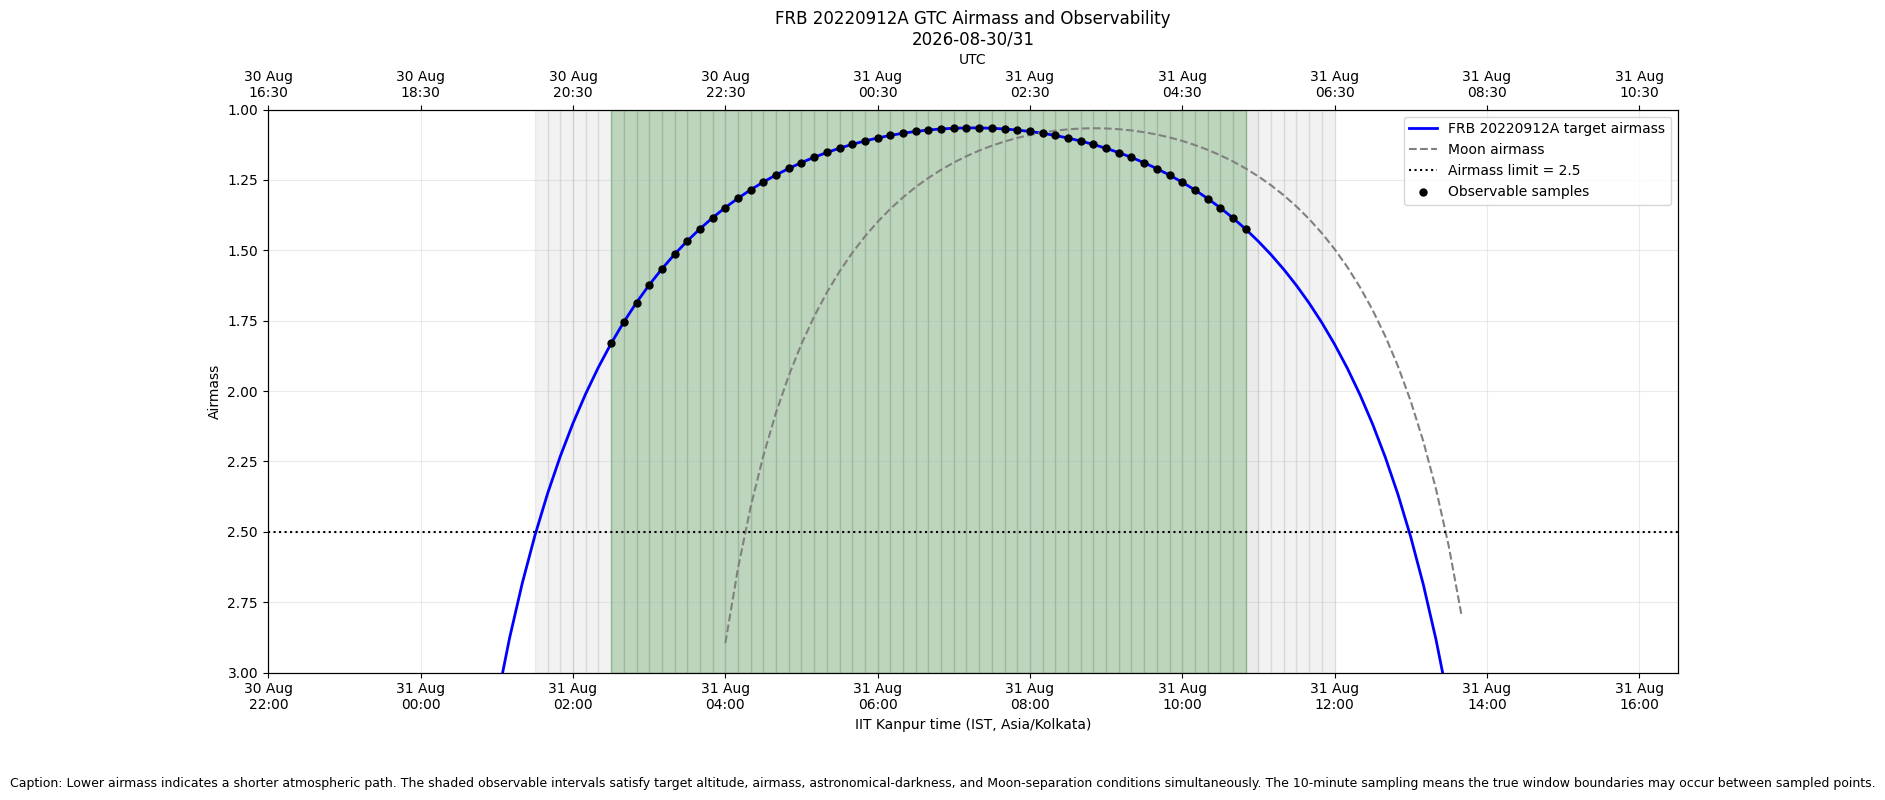


Figure saved to:
assignment_outputs/frb_20220912a_gtc_airmass.png
File exists: True
File size: 266175 bytes


In [20]:
def stitch_windows(times, visibility_state):
    """
    Return consecutive inclusive sample-centre intervals.

    Each returned item contains:
    (start_index, end_index, start_time, end_time)
    """

    visibility_state = np.asarray(
        visibility_state,
        dtype=bool
    )

    if len(times) != len(visibility_state):
        raise ValueError(
            "times and visibility_state must have equal length."
        )

    windows = []
    start = None

    for i, visible in enumerate(visibility_state):

        if visible and start is None:
            start = i

        # End of a window
        if start is not None:
            is_last = (i == len(visibility_state) - 1)
            next_is_hidden = (
                not visibility_state[i + 1]
                if not is_last
                else True
            )

            if is_last or next_is_hidden:
                windows.append(
                    (
                        start,
                        i,
                        times[start],
                        times[i]
                    )
                )
                start = None

    return windows


# Find observing windows
observing_windows = stitch_windows(
    times,
    preferred_visibility
)

print("OBSERVING WINDOWS")
print("=================")

if not observing_windows:
    print("No observing windows found.")

else:

    for number, (
        start_index,
        end_index,
        start_time,
        end_time
    ) in enumerate(observing_windows, start=1):

        duration_hours = (
            end_time - start_time
        ).to_value(u.hour)

        window_airmass = target_airmass[
            start_index:end_index + 1
        ]

        best_local_index = np.nanargmin(
            window_airmass
        )

        best_global_index = (
            start_index + best_local_index
        )

        best_airmass = target_airmass[
            best_global_index
        ]

        midpoint_index = (
            start_index + end_index
        ) // 2

        print(f"\nWindow {number}")
        print("Start UTC:",
              format_utc(start_time))
        print("Start IST:",
              format_iitk(start_time))

        print("End UTC:",
              format_utc(end_time))
        print("End IST:",
              format_iitk(end_time))

        print("Sample-centre duration:",
              duration_hours,
              "hours")

        print("Best target airmass:",
              best_airmass)

        print("Midpoint Moon label:",
              moon_labels[midpoint_index])


# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 8)
)

# Convert times to Python datetimes in IST
ist_datetimes = [
    t.to_datetime(timezone=IITK_TIMEZONE)
    for t in times
]

# Target airmass
ax.plot(
    ist_datetimes,
    target_airmass,
    color="blue",
    linewidth=2,
    label="FRB 20220912A target airmass"
)

# Moon airmass
moon_airmass_plot = np.asarray(
    moon_airmass,
    dtype=float
)

ax.plot(
    ist_datetimes,
    moon_airmass_plot,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Moon airmass"
)

# Airmass limit
ax.axhline(
    MAX_AIRMASS,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Airmass limit = 2.5"
)

# ---------------------------------------------------------
# Twilight / night bands
# ---------------------------------------------------------

night = (
    sun_altitude <= -18
)

civil_twilight = (
    (sun_altitude > -18)
    & (sun_altitude <= -6)
)

daylight = (
    sun_altitude > -6
)

# Shade regions sample-by-sample
for i in range(len(times) - 1):

    if night[i]:
        ax.axvspan(
            ist_datetimes[i],
            ist_datetimes[i + 1],
            color="black",
            alpha=0.08
        )

    elif civil_twilight[i]:
        ax.axvspan(
            ist_datetimes[i],
            ist_datetimes[i + 1],
            color="gray",
            alpha=0.10
        )

# ---------------------------------------------------------
# Observable intervals
# ---------------------------------------------------------

for start_index, end_index, start_time, end_time in observing_windows:

    ax.axvspan(
        ist_datetimes[start_index],
        ist_datetimes[end_index],
        color="green",
        alpha=0.20
    )

# Observable sample markers
observable_indices = np.where(
    preferred_visibility
)[0]

ax.scatter(
    np.array(ist_datetimes)[observable_indices],
    target_airmass[observable_indices],
    color="black",
    s=25,
    zorder=5,
    label="Observable samples"
)

# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------

ax.set_ylim(
    3,
    1
)

ax.set_ylabel(
    "Airmass"
)

ax.set_xlabel(
    "IIT Kanpur time (IST, Asia/Kolkata)"
)

ax.set_title(
    "FRB 20220912A GTC Airmass and Observability\n"
    "2026-08-30/31"
)

# Date rollover
ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b\n%H:%M",
        tz=IITK_TIMEZONE
    )
)

ax.grid(
    True,
    alpha=0.25
)

# ---------------------------------------------------------
# Aligned UTC axis
# ---------------------------------------------------------

ax_utc = ax.twiny()

ax_utc.set_xlim(
    ax.get_xlim()
)

# Use the same positions as the main x-axis
ticks = ax.get_xticks()

ax_utc.set_xticks(ticks)

# Convert Matplotlib date numbers from IST display
# into UTC labels
utc_labels = []

for tick in ticks:

    dt_ist = mdates.num2date(
        tick,
        tz=IITK_TIMEZONE
    )

    dt_utc = dt_ist.astimezone(
        timezone.utc
    )

    utc_labels.append(
        dt_utc.strftime("%d %b\n%H:%M")
    )

ax_utc.set_xticklabels(
    utc_labels
)

ax_utc.set_xlabel(
    "UTC"
)

# Legend
ax.legend(
    loc="upper right"
)

# Caption
fig.text(
    0.5,
    0.01,
    "Caption: Lower airmass indicates a shorter atmospheric path. "
    "The shaded observable intervals satisfy target altitude, "
    "airmass, astronomical-darkness, and Moon-separation conditions "
    "simultaneously. The 10-minute sampling means the true window "
    "boundaries may occur between sampled points.",
    ha="center",
    fontsize=9
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

# Save required figure
output_path = (
    OUTPUT_DIR
    / "frb_20220912a_gtc_airmass.png"
)

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)
print("File exists:", output_path.exists())
print("File size:", output_path.stat().st_size, "bytes")

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [21]:
# Full UTC day on 2026-09-01
q19_start = Time(
    "2026-09-01T00:00:00",
    scale="utc"
)

q19_stop = Time(
    "2026-09-02T00:00:00",
    scale="utc"
)

# Use 1-minute sampling for the daily visibility calculation
q19_step = 1 * u.min

q19_number_of_steps = int(
    np.round(
        (
            (q19_stop - q19_start)
            / q19_step
        ).to_value(
            u.dimensionless_unscaled
        )
    )
)

q19_times = (
    q19_start
    + np.arange(q19_number_of_steps + 1)
    * q19_step
)

# Target AltAz
q19_altaz = frb_icrs.transform_to(
    AltAz(
        obstime=q19_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

q19_altitude = q19_altaz.alt.to_value(
    u.deg
)

q19_airmass = np.asarray(
    q19_altaz.secz,
    dtype=float
)

# Safe airmass
q19_airmass[
    (
        (q19_altitude <= 0)
        | (~np.isfinite(q19_airmass))
        | (q19_airmass < 1)
    )
] = np.nan

# Sun altitude
q19_sun = get_sun(q19_times)

q19_sun_altaz = q19_sun.transform_to(
    AltAz(
        obstime=q19_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

q19_sun_altitude = q19_sun_altaz.alt.to_value(
    u.deg
)

# Visibility rule for Q19:
# astronomical night + altitude above horizon +
# airmass <= 2.5
q19_visible = (
    (q19_altitude >= 0)
    & np.isfinite(q19_airmass)
    & (q19_airmass <= MAX_AIRMASS)
    & (q19_sun_altitude <= MAX_SUN_ALTITUDE_DEG)
)


# ---------------------------------------------------------
# Find contiguous intervals
# ---------------------------------------------------------

q19_windows = []

start_index = None

for i, visible in enumerate(q19_visible):

    if visible and start_index is None:
        start_index = i

    if start_index is not None:

        is_last = (
            i == len(q19_visible) - 1
        )

        next_hidden = (
            not q19_visible[i + 1]
            if not is_last
            else True
        )

        if is_last or next_hidden:

            q19_windows.append(
                (
                    start_index,
                    i
                )
            )

            start_index = None


# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------

print("Q19 — FRB 20220912A visibility on 2026-09-01")
print("=" * 60)

if not q19_windows:

    print("No visibility intervals found.")

else:

    total_duration = 0.0

    for number, (
        start_index,
        end_index
    ) in enumerate(q19_windows, start=1):

        start_time = q19_times[start_index]
        end_time = q19_times[end_index]

        duration = (
            end_time - start_time
        ).to_value(u.hour)

        total_duration += duration

        print(f"\nVisibility interval {number}")

        print(
            "Start UTC:",
            format_utc(start_time)
        )

        print(
            "Start IST:",
            format_iitk(start_time)
        )

        print(
            "End UTC:",
            format_utc(end_time)
        )

        print(
            "End IST:",
            format_iitk(end_time)
        )

        print(
            "Duration:",
            duration,
            "hours"
        )

    print("\nTotal visible duration:",
          total_duration,
          "hours")

Q19 — FRB 20220912A visibility on 2026-09-01

Visibility interval 1
Start UTC: 2026-09-01 00:00:00 UTC
Start IST: 2026-09-01 05:30:00 IST
End UTC: 2026-09-01 05:28:00 UTC
End IST: 2026-09-01 10:58:00 IST
Duration: 5.466666666666666 hours

Visibility interval 2
Start UTC: 2026-09-01 20:55:00 UTC
Start IST: 2026-09-02 02:25:00 IST
End UTC: 2026-09-02 00:00:00 UTC
End IST: 2026-09-02 05:30:00 IST
Duration: 3.083333333333333 hours

Total visible duration: 8.549999999999999 hours


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [22]:
# Moderate HEALPix resolution
nside = 16

npix = hp.nside2npix(nside)

# Weekly dates
weekly_dates = [
    q
    for q in (
        Time("2026-08-30", scale="utc")
        + np.arange(53) * 7 * u.day
    )
    if q <= Time("2027-08-29", scale="utc")
]

q20_output_dir = OUTPUT_DIR / "q20_frames"
q20_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

frame_paths = []

# HEALPix pixel centres
theta, phi_hp = hp.pix2ang(
    nside,
    np.arange(npix)
)

# Convert HEALPix angles:
# theta = colatitude
# phi = longitude
dec_hp = (np.pi / 2) - theta
ra_hp = phi_hp

sky_positions = SkyCoord(
    ra=ra_hp * u.rad,
    dec=dec_hp * u.rad,
    frame="icrs"
)

for frame_number, date in enumerate(weekly_dates):

    # Use the middle of the UTC day as a representative
    # observing time for that date
    observation_time = date + 12 * u.hour

    altaz_frame = AltAz(
        obstime=observation_time,
        location=gtc_location,
        pressure=0 * u.hPa
    )

    sky_altaz = sky_positions.transform_to(
        altaz_frame
    )

    altitude = sky_altaz.alt.to_value(
        u.deg
    )

    airmass = np.asarray(
        sky_altaz.secz,
        dtype=float
    )

    # Sun altitude
    sun_position = get_sun(
        observation_time
    )

    sun_altaz = sun_position.transform_to(
        altaz_frame
    )

    sun_altitude_value = sun_altaz.alt.to_value(
        u.deg
    )

    # Visibility:
    # above horizon + airmass <= 2.5 +
    # astronomical darkness
    visible_map = (
        (altitude >= 0)
        & np.isfinite(airmass)
        & (airmass >= 1)
        & (airmass <= MAX_AIRMASS)
        & (sun_altitude_value <= MAX_SUN_ALTITUDE_DEG)
    )

    # Create HEALPix map
    healpix_map = visible_map.astype(float)

    # Plot
    fig = plt.figure(
        figsize=(10, 6)
    )

    hp.mollview(
        healpix_map,
        fig=fig.number,
        title=(
            "GTC All-Sky Visibility\n"
            + date.utc.isot[:10]
        ),
        coord=["C"],
        unit="Visible = 1, Not visible = 0",
        min=0,
        max=1,
        cbar=True
    )

    frame_path = (
        q20_output_dir
        / f"frame_{frame_number:03d}.png"
    )

    plt.savefig(
        frame_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(fig)

    frame_paths.append(
        frame_path
    )

print(
    "Generated",
    len(frame_paths),
    "weekly HEALPix frames."
)

# ---------------------------------------------------------
# Create GIF
# ---------------------------------------------------------

import imageio.v2 as imageio

gif_path = (
    OUTPUT_DIR
    / "q20_gtc_visibility.gif"
)

images = [
    imageio.imread(path)
    for path in frame_paths
]

imageio.mimsave(
    gif_path,
    images,
    duration=0.25,
    loop=0
)

print("GIF saved to:")
print(gif_path)

print("GIF exists:",
      gif_path.exists())

print(
    "GIF size:",
    gif_path.stat().st_size,
    "bytes"
)

/usr/local/lib/python3.13/dist-packages/healpy/visufunc.py:225: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


Generated 53 weekly HEALPix frames.
GIF saved to:
assignment_outputs/q20_gtc_visibility.gif
GIF exists: True
GIF size: 177221 bytes


The observable region changes throughout the year because the apparent positions of celestial coordinates relative to the Sun and the local observing geometry change with date. As the year progresses, different parts of the celestial sphere become available during astronomical night from GTC. The animation therefore shows the seasonal change in the region of sky satisfying the altitude, airmass, and darkness conditions.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
